수만 장에 달하는 기존의 이미지에서 학습한 정보를 가져와 내 프로젝트에 활용하는 것을 전이 학습(transfer learning)이라고 한다.

딥러닝 및 머신러닝 알고리즘은 크게 두 가지 유형으로 나뉜다. 정답을 알려 주고 시작하는가 아닌가에 따라 지도 학습(supervised learning) 방식과 비지도 학습(unsupervised learning) 방식으로 구분된다.

이번에 진행할 프로젝트는 MRI 뇌 사진을 보고 치매 환자의 뇌인지, 일반인의 뇌인지 예측하는 것이다.  
총 280장으로 이루어진 뇌의 단면사진이 있으며, 치매 환자의 특성을 보이는 뇌 사진 140장과 일반일의 뇌 사진 140장으로 구성되어 있다.  280개의 이미지 중 160개는 train 폴더, 120개는 test 폴더에 있으며, 치매 환자의 뇌 사진은 ad 폴더에, 일반인 뇌 사진은 normal 폴더에 저장되어 있다.



데이터 수를 늘리는 ImageDataGenerator() 함수와 폴더에 저장된 데이터를 불러오는 flow_from_directory() 함수를 사용한다.  
ImageDataGengerator() 함수는 주어진 데이터를 이용해 변형된 이미지를 만들어 학습셋에 포함시키는 편리한 기능을 제공한다. 이미지 데이터 수를 확장할 때 효과적으로 사용할 수 있다.

다음은 함수를 사용한 예이다.


```
train_datagen = ImageDataGenerator(rescale=1./255,
                                   horizental_flip=True,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1,
                                   rotation_range=5,
                                   shear_range=0.7,
                                   zoom_range=1.2,
                                   vertical_flip=True,
                                   fill_mode='nearest')
```

각각 인자에 대한 설명은 다음과 같다.
- rescale: 주어진 이미지의 크기를 바꾸어 준다. 예를 들어 원본 영상이 0 ~ 255의 RGB 값을 가지고 있으므로 255로 나누면 0~1 값으로 변환되어 학습이 좀 더 빠르고 쉬워진다. 정규화 과정과 같다.
- horizental_flip, vertical_flip: 주어진 이미지를 수평 또는 수직으로 뒤집는다.
- zoom_range: 정해진 범위 안에서 축소 또는 확대한다.
- width_shilf_range, height_shift_range: 정해진 범위 안에서 그림을 수평 또는 수직으로 랜덤하게 평행 이동시킨다.
- rotation_range: 정해진 각도만큼 이미지를 회전시킨다.
- shear_range: 좌표 하나를 고정시키고 다른 몇 개의 좌표를 이동시키는 변환을 한다.
- fill_range: 이미지를 축소 또는 회전하거나 이동할 때 생기는 빈 공간을 어떻게 채울지 결정한다. nearest 옵션을 선택하면 가장 비슷한 색으로 채워진다.  
단, 이 모든 인자를 다 적용하면 불필요한 데이터를 만들게 되어 오히려 학습 시간이 늘어난다는 것에 주의해야 한다.  
참고로 데이터 부풀리기는 학습셋에만 적용하는 것이 좋다. 테스트셋은 실제 정보를 그대로 유지하게 하는 편이 과적합의 위험을 줄일 수 있기 때문이다.

테스트셋은 다음과 같이 정규화만 진행해준다.

```
test_datagen = ImageDataGenerator(rescale=1./255)
```



이미지 생성 옵션을 정하고 나면 실제 데이터가 있는 곳을 알려주고 이미지를 불러오는 작업을 해야한다.

```
train_generator = train_datagen.flow_from_directory(
    './bata-ch20/train',    # 학습셋이 있는 폴더 위치
    target_size=(150, 150), # 이미지 크기
    batch_size=5,
    class_mode='binary')    # 치매/정산 이진 분류이므로 바이너리 모드로 실행
```



같은 과정을 거쳐서 테스트셋도 생성해준다.


```
test_generator = test_datagen.flow_from_directory(
    './data-ch20/test'      # 테스트셋이 있는 폴더 위치
    target_size=(150, 150),
    batch_size=5,
    class_mode='binary')
```



모델 실행을 위한 옵션을 만들어준다.  
옵티마이저로 Adam을 선택하는데, 이번에는 케라스 API의 optimizers 클래스를 이용해 학습률을 따로 지정해 보았다. 조기 중단을 설정하고 model.fit()을 실행하는데, 이때 학습셋과 검증셋을 조금 전 만들어 준 train_generator와 test_generator로 지정한다.

```
# 모델의 실행 옵션을 설정한다.
model.compile(loss='binary_crossentropy', optimizer=optimizers.Adam
              (learning_rate=0.0002), metrics=['accuracy'])

# 학습의 조기 중단을 설정한다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델을 실행한다.
 history = model.fit(train_generator,
                     epochs=100,
                     validation_data=test_generator,
                     validation_steps=10,
                     callbacks=[early_stopping_callback])
```



CNN을 이용해 모델을 만들어본다.

실습| 치매 환자의 뇌인지 일반인의 뇌인지 예측하기

fatal: destination path 'data-ch20' already exists and is not an empty directory.
Found 160 images belonging to 2 classes.
Found 120 images belonging to 2 classes.
Epoch 1/100
32/32 [==============================] - 14s 47ms/step - loss: 0.6982 - accuracy: 0.5375 - val_loss: 0.6758 - val_accuracy: 0.5400
Epoch 2/100
32/32 [==============================] - 2s 52ms/step - loss: 0.6896 - accuracy: 0.5188 - val_loss: 0.6943 - val_accuracy: 0.5400
Epoch 3/100
32/32 [==============================] - 2s 52ms/step - loss: 0.6848 - accuracy: 0.5437 - val_loss: 0.6671 - val_accuracy: 0.6800
Epoch 4/100
32/32 [==============================] - 1s 42ms/step - loss: 0.6628 - accuracy: 0.6250 - val_loss: 0.6145 - val_accuracy: 0.7800
Epoch 5/100
32/32 [==============================] - 2s 52ms/step - loss: 0.6365 - accuracy: 0.6125 - val_loss: 0.6377 - val_accuracy: 0.6800
Epoch 6/100
32/32 [==============================] - 3s 84ms/step - loss: 0.6377 - accuracy: 0.6500 - val_loss: 0.5829 - val_

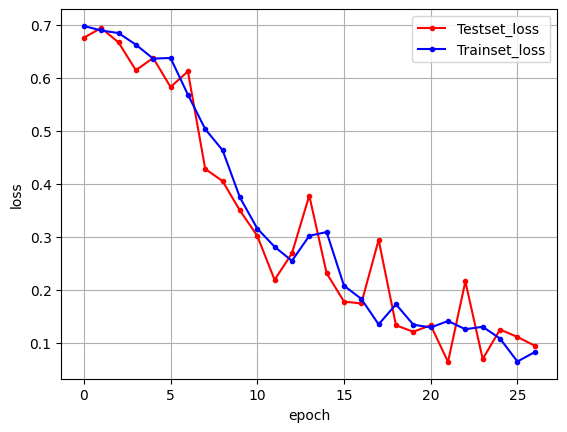

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers

import numpy as np
import matplotlib.pyplot as plt

# 깃허브에 준비된 데이터를 가져온다.
!git clone https://github.com/taehojo/data-ch20.git

# 학습셋의 변형을 설정하는 부분이다.
train_datagen = ImageDataGenerator(rescale=1./255,          # 주어진 이미지 크키를 설정
                                   horizontal_flip=True,    # 수평 대칭 이미지를 50% 확률로 만들어 추가한다.
                                   width_shift_range=0.1,   # 전체 크기의 15% 범위에서 좌우로 이동한다.
                                   height_shift_range=0.1,  # 마찬가지로 위아래로 이동한다.
                                   # rotation_range=5,      # 정해진 각도만큼 회전시킨다.
                                   # shear_range=0.7,       # 좌표 하나를 고정시키고 나머지를 이동시킨다.
                                   # zoom_range=[0.9, 2.2], # 확대 또는 축소시킨다.
                                   # vertical_flip=True,    # 수직 대칭 이미지를 만든다.
                                   # fill_mode='nearest'    # 빈 공간을 채우는 방법이다.
                                   #                        # nearest 옵션은 가장 비슷한 색으로 채우게 된다.
                                   )

train_generator = train_datagen.flow_from_directory(
    './data-ch20/train',    # 학습셋이 있는 폴더의 위치이다.
    target_size=(150, 150),
    batch_size=5,
    class_mode='binary')

# 테스트셋은 이미지 부풀리기 과정을 진행하지 않는다.
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = train_datagen.flow_from_directory(
    './data-ch20/test',     # 테스트셋이 있는 폴더의 위치이다.
    target_size=(150, 150),
    batch_size=5,
    class_mode='binary')

# 앞서 배운 CNN 모델을 만들어 적용해 본다.
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(150, 150, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

# 모델 실행의 옵션을 설정한다.
model.compile(loss='binary_crossentropy', optimizer=optimizers.Adam
              (learning_rate=0.0002), metrics=['accuracy'])

# 학습의 조기 중단을 설정한다.
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델을 실행한다.
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=test_generator,
    validation_steps=10,
    callbacks=[early_stopping_callback])

# 검증셋과 학습셋의 오차를 저장한다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시한다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()